In [ ]:
import os
import random
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import torch
import torchvision.models as models
import torchvision.transforms as transforms


from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Caratcerísticas del dataset

Carga de datasets de tortugas (YoutubeTurtles), ballenas (YoutubeWhales) y tiburones (RoboflowSharks):

In [ ]:
!rm -rf temp_dataset
!mkdir temp_dataset

!cp -r database/YoutubeTurtles temp_dataset/

!python helper_scripts/03_dataset_feature_extractor.py --dataset_root temp_dataset --output output/youtube_turtles_features.csv

^C
Processing YoutubeTurtles/N877Supplement_1 ...
Processing YoutubeTurtles/XoEC0D1W5Nw_t=148 ...
Processing YoutubeTurtles/lost_video ...
Processing YoutubeTurtles/watch_v=-oTxoHXIC4E&t=50s ...
Processing YoutubeTurtles/watch_v=AC1ffLCRdVM&ab_channel=DanielGomez ...
Processing YoutubeTurtles/watch_v=FzIPv3aMI-4&ab_channel=SHIBATOD ...
Processing YoutubeTurtles/watch_v=FzLyTZs7Yzo&ab_channel=JavierVargas ...
Processing YoutubeTurtles/watch_v=Ui9Boo1t9ZU&ab_channel=JayLevins ...
Processing YoutubeTurtles/watch_v=c8vjHn9UmO8&ab_channel=SPMediaProduction ...
Processing YoutubeTurtles/watch_v=rj8HPtU6uxc&t=2s&ab_channel=PeterKragh ...

Saved 10 rows to output/youtube_turtles_features.csv


In [ ]:
turtles_df = pd.read_csv("output/youtube_turtles_features.csv")

turtles_df.head()

,dataset_id,media_id,n_images,n_annotations,mean_instances,mean_box_w,mean_box_h,mean_brightness,mean_contrast,is_dark
0,YoutubeTurtles,-nl3a1dsvv0,46,482,10.478,0.0344,0.0582,113.83,28.95,0.0
1,YoutubeTurtles,5nTrx9k1dVU_t=38,14,14,1.000,0.0633,0.0963,132.62,15.12,0.0
2,YoutubeTurtles,N877Supplement_1,76,76,1.000,0.1096,0.1431,130.51,22.23,0.0
3,YoutubeTurtles,Supp video 1 captioned,8,8,1.000,0.1057,0.1655,142.60,24.93,0.0
4,YoutubeTurtles,Supp video 3 captioned,23,38,1.652,0.0648,0.0903,139.54,22.20,0.0


In [ ]:
!rm -rf temp_dataset
!mkdir temp_dataset

!cp -r database/YoutubeWhales temp_dataset/

!python helper_scripts/03_dataset_feature_extractor.py --dataset_root temp_dataset --output output/whales_features.csv

^C
Processing YoutubeWhales/Documentario_UmatemporadadasBaleiasnaBahiaWhalewatchingdocumentary ...
Processing YoutubeWhales/Dowhalesandhumansspeakthesamelanguage ...
Processing YoutubeWhales/KillingtoSurviveHuntingOrcasonthePatagoniancoast ...
Processing YoutubeWhales/NEWPORTCOASTALADVENTUREWHALEWATCHINGTRIP ...
Processing YoutubeWhales/OceanEncounters_SavingtheNorthAtlanticRightWhale ...
Processing YoutubeWhales/WhaleDocumentary2021_AnimalDocumentary20214KHD ...
Processing YoutubeWhales/WhalesinaChangingOcean ...
Processing YoutubeWhales/oceansmauritius ...

Saved 7 rows to output/whales_features.csv


In [ ]:
whales_df = pd.read_csv("output/whales_features.csv")

whales_df.head()

,dataset_id,media_id,n_images,n_annotations,mean_instances,mean_box_w,mean_box_h,mean_brightness,mean_contrast,is_dark
0,YoutubeWhales,Documentario_UmatemporadadasBaleiasnaBahiaWhal...,857,1423,1.660,0.2334,0.3046,74.84,30.92,0.004
1,YoutubeWhales,Dowhalesandhumansspeakthesamelanguage,78,156,2.000,0.1247,0.2320,83.92,26.89,0.000
2,YoutubeWhales,KillingtoSurviveHuntingOrcasonthePatagoniancoast,119,138,1.160,0.2932,0.4619,64.94,30.14,0.084
3,YoutubeWhales,OceanEncounters_SavingtheNorthAtlanticRightWhale,26,31,1.192,0.1949,0.6233,127.58,82.11,0.000
4,YoutubeWhales,WhaleDocumentary2021_AnimalDocumentary20214KHD,19,19,1.000,0.2358,0.3276,77.67,24.53,0.000


In [ ]:
!rm -rf temp_dataset
!mkdir temp_dataset

!cp -r database/RoboflowSharks temp_dataset/

!python helper_scripts/03_dataset_feature_extractor.py --dataset_root temp_dataset --output output/sharks_features.csv

^C
Processing RoboflowSharks/folder_001 ...
Processing RoboflowSharks/folder_007 ...
Processing RoboflowSharks/folder_009 ...
Processing RoboflowSharks/folder_012 ...
Processing RoboflowSharks/folder_013 ...
Processing RoboflowSharks/folder_014 ...
Processing RoboflowSharks/folder_015 ...
Processing RoboflowSharks/folder_022 ...
Processing RoboflowSharks/folder_023 ...
Processing RoboflowSharks/folder_024 ...
Processing RoboflowSharks/folder_025 ...
Processing RoboflowSharks/folder_031 ...
Processing RoboflowSharks/folder_036 ...
Processing RoboflowSharks/folder_038 ...
Processing RoboflowSharks/folder_039 ...
Processing RoboflowSharks/folder_040 ...
Processing RoboflowSharks/folder_041 ...
Processing RoboflowSharks/folder_046 ...
Processing RoboflowSharks/folder_047 ...
Processing RoboflowSharks/folder_048 ...
Processing RoboflowSharks/folder_049 ...
Processing RoboflowSharks/folder_053 ...
Processing RoboflowSharks/folder_054 ...
Processing RoboflowSharks/folder_062 ...
Processing Ro

In [ ]:
sharks_df = pd.read_csv("output/sharks_features.csv")

sharks_df.head()

,dataset_id,media_id,n_images,n_annotations,mean_instances,mean_box_w,mean_box_h,mean_brightness,mean_contrast,is_dark
0,RoboflowSharks,folder_007,100,104,1.04,0.0653,0.1197,105.63,17.18,0.0
1,RoboflowSharks,folder_009,100,114,1.14,0.0678,0.1159,107.20,17.25,0.0
2,RoboflowSharks,folder_012,100,103,1.03,0.0820,0.1382,109.27,16.88,0.0
3,RoboflowSharks,folder_013,100,118,1.18,0.0632,0.1007,108.17,16.31,0.0
4,RoboflowSharks,folder_014,100,111,1.11,0.0794,0.1155,106.05,17.16,0.0


In [ ]:
!sed -i 's/len(parts) == 5/len(parts) >= 5/g' helper_scripts/03_dataset_feature_extractor.py

Comparación de características:

In [ ]:
# Se combinan los datasets para crear una tabla comparativa

df = pd.concat([
    turtles_df,
    whales_df,
    sharks_df
])

summary = df.groupby("dataset_id").agg({

    "media_id": "count",
    "n_images": "sum",
    "n_annotations": "sum",
    "mean_box_w": "mean",
    "mean_box_h": "mean",
    "mean_brightness": "mean",
    "mean_contrast": "mean"

}).reset_index()

# Se calculan las medias por secuencia y las columnas de interés
summary["Mean images/media"] = (
    summary["n_images"] / summary["media_id"]
).round(0).astype(int)

summary["Mean annotations/media"] = (
    summary["n_annotations"] / summary["media_id"]
).round(0).astype(int)

summary = summary[[
    "dataset_id",
    "n_images",
    "Mean images per media",
    "n_annotations",
    "Mean annotations per media",
    "mean_box_w",
    "mean_box_h",
    "mean_brightness",
    "mean_contrast"
]]

summary.columns = [
    "Dataset",
    "Total images",
    "Mean images per media",
    "Total annotations",
    "Mean annotations per media",
    "Mean box width",
    "Mean box height",
    "Mean brightness",
    "Mean contrast"
]

# Se genera la tabla y se almacena

print("\n================ DATASET SUMMARY ================\n")

print(summary.to_string(index=False))

summary.to_csv(
    "output/multiclass_dataset_summary_clean.csv",
    index=False
)

print("\nSaved:")
print("output/multiclass_dataset_summary_clean.csv")


================ DATASET SUMMARY ================

       Dataset  Total images  Mean images per media  Total annotations  Mean annotations per media  Mean box width  Mean box height  Mean brightness  Mean contrast
RoboflowSharks          3800                    100               4089                         108            0.08             0.10           105.31          15.60
YoutubeTurtles          1684                     44               3312                          87            0.08             0.12           120.51          24.26
 YoutubeWhales          5959                    271               9345                         425            0.20             0.29            92.02          37.71

Saved:
output/multiclass_dataset_summary_clean.csv


# Embeddings profundos


Loaded 450 images


100%|██████████| 450/450 [00:58<00:00,  7.69it/s]



Embeddings shape: (450, 512)


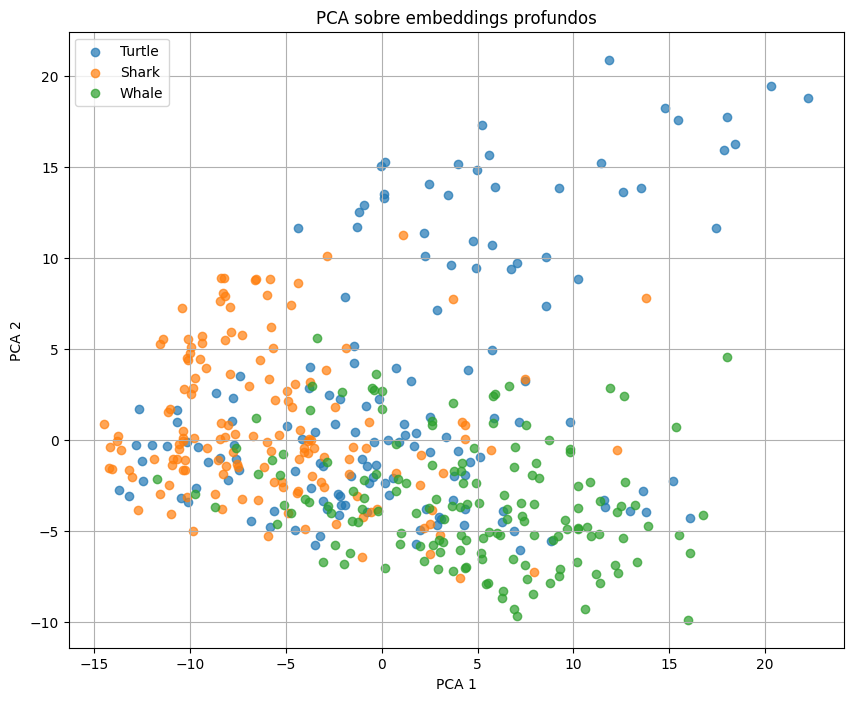

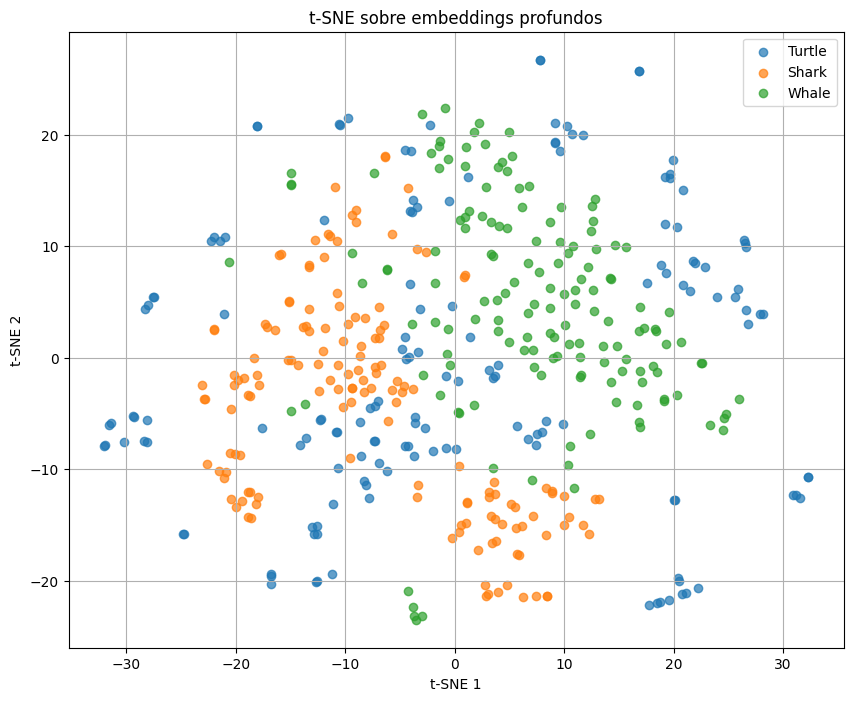

In [ ]:
DATASETS = {
    "Turtle": "database/YoutubeTurtles",
    "Shark": "database/RoboflowSharks",
    "Whale": "database/YoutubeWhales"
}

MAX_IMAGES_PER_CLASS = 150
IMAGE_SIZE = 224
RANDOM_SEED = 42

random.seed(RANDOM_SEED)


# Se carga el modelo ResNet18 preentrenado
model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

# Se elimina la capa de clasificación final para utilizar únicamente los
# embeddings profundos generados por la red
model = torch.nn.Sequential(
    *list(model.children())[:-1]
)

model.eval()

# Transformación de imágenes

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Carga de imágenes

samples = []

for class_name, dataset_path in DATASETS.items():

    image_paths = list(Path(dataset_path).rglob("*.jpg"))
    image_paths += list(Path(dataset_path).rglob("*.png"))
    image_paths += list(Path(dataset_path).rglob("*.jpeg"))

    random.shuffle(image_paths)

    image_paths = image_paths[:MAX_IMAGES_PER_CLASS]

    for path in image_paths:

        samples.append({
            "class": class_name,
            "path": path
        })

print(f"\nLoaded {len(samples)} images")


# Se extraen los embeddings profundos

embeddings = []
labels = []

for sample in tqdm(samples):

    image = cv2.imread(str(sample["path"]))

    if image is None:
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    tensor = transform(image).unsqueeze(0)

    with torch.no_grad():

        embedding = model(tensor)

    embedding = embedding.squeeze().numpy()

    embeddings.append(embedding)
    labels.append(sample["class"])

embeddings = np.array(embeddings)

print("\nEmbeddings shape:", embeddings.shape)

# Normalización de características antes de aplicar reducción de dimensionalidad

scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(embeddings)


########## PCA

pca = PCA(n_components=2)

pca_result = pca.fit_transform(embeddings_scaled)

pca_df = pd.DataFrame({
    "PCA1": pca_result[:, 0],
    "PCA2": pca_result[:, 1],
    "Class": labels
})

# Visualización PCA

plt.figure(figsize=(10, 8))

for class_name in pca_df["Class"].unique():

    subset = pca_df[pca_df["Class"] == class_name]

    plt.scatter(
        subset["PCA1"],
        subset["PCA2"],
        label=class_name,
        alpha=0.7
    )

plt.title("PCA sobre embeddings profundos")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.grid(True)

plt.show()

########## t-SNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=RANDOM_SEED
)

tsne_result = tsne.fit_transform(embeddings_scaled)

tsne_df = pd.DataFrame({
    "TSNE1": tsne_result[:, 0],
    "TSNE2": tsne_result[:, 1],
    "Class": labels
})

# Visualización t-SNE

plt.figure(figsize=(10, 8))

for class_name in tsne_df["Class"].unique():

    subset = tsne_df[tsne_df["Class"] == class_name]

    plt.scatter(
        subset["TSNE1"],
        subset["TSNE2"],
        label=class_name,
        alpha=0.7
    )

plt.title("t-SNE sobre embeddings profundos")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend()
plt.grid(True)

plt.show()